## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import shapely

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

# for parsing HTML inside the Description field
from bs4 import BeautifulSoup

In [3]:
from gridsample.utils import save_shapefiles

In [4]:
INDIA_PROJECTED_CRS = "24378"

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"

In [6]:
# Function to add suffix to duplicates
def add_suffix_to_duplicates(series):
    counts = {}
    result = []
    for item in series:
        if item in counts:
            counts[item] += 1
            result.append(f"{item}_S{counts[item]}")
        else:
            counts[item] = 0
            result.append(item)
    return result

In [7]:
# Parse description variables


def description_parser_single_row(html_content):
    # Parse the HTML content
    soup = BeautifulSoup(html_content, "html.parser")

    # Find the inner table containing the attributes
    inner_table = soup.find_all("table")[1]

    # Extract rows from the inner table
    rows = inner_table.find_all("tr")

    # Create a dictionary to store attributes and their values
    data = {}
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            key = cols[0].text.strip()
            value = cols[1].text.strip()
            data[key] = value

    return pd.DataFrame([data])


def description_parser(df, description_col_name="Description"):
    # make dataframe of variables
    data = [
        description_parser_single_row(df[description_col_name].values[i])
        for i in range(len(df))
    ]
    df_vars = pd.concat(data)
    df_vars.set_index(df.index, inplace=True)

    return df_vars

## Load raw shapes and process

### Dhar

In [ ]:
# Load dhar khasras
raw_dhar_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Dhar Khasras" / "doc.kml", driver="KML"
)

In [ ]:
# remove z-dimension
raw_dhar_gdf.geometry = raw_dhar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons and only keep the polygon
raw_dhar_gdf = raw_dhar_gdf.explode(index_parts=False)
raw_dhar_gdf = raw_dhar_gdf[raw_dhar_gdf.geometry.type == "Polygon"]

# remove useless Description column
dhar_gdf = raw_dhar_gdf.drop(columns="Description")

In [ ]:
# drop large green shapes (open .KMZ on Google Earth to see)
dhar_gdf = dhar_gdf[dhar_gdf["Name"] != ""]

In [ ]:
# clean up Name so we can separate the villages (string names) from the areas (numbers only)
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["Name"].str.split("/")
]
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["cleaned_name"].str.split(",")
]

In [ ]:
# manual clean
dhar_gdf.loc[dhar_gdf["Name"] == "2829Z1", "cleaned_name"] = "2829"

In [ ]:
# ISOLATE AREA ONLY - select rows that have a number as their Name
dhar_yellow_shapes_gdf = dhar_gdf[dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_yellow_shapes_gdf.plot()

In [ ]:
# ISOLATE VILLAGES ONLY - select rows that have a string as their Name
dhar_village_shapes_gdf = dhar_gdf[~dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_village_shapes_gdf = dhar_village_shapes_gdf.drop(columns="cleaned_name")
dhar_village_shapes_gdf = dhar_village_shapes_gdf.rename(
    columns={"Name": "village_name"}
)
dhar_village_shapes_gdf.plot(column="village_name")

In [ ]:
# add village names to areas
dhar_processed_areas_gdf = dhar_yellow_shapes_gdf.sjoin(
    dhar_village_shapes_gdf, how="left", predicate="intersects"
).drop(columns="index_right")
dhar_processed_areas_gdf.plot(column="village_name")
print("Missing village name:", dhar_processed_areas_gdf["village_name"].isnull().sum())
print("Has village name:", dhar_processed_areas_gdf["village_name"].notnull().sum())

In [ ]:
# Apply the function to the khasra_id column
dhar_processed_areas_gdf["khasra_id"] = dhar_processed_areas_gdf["Name"]
dhar_processed_areas_gdf["khasra_id"] = add_suffix_to_duplicates(
    dhar_processed_areas_gdf["khasra_id"]
)

In [ ]:
dhar_processed_areas_gdf.drop(columns="cleaned_name", inplace=True)

In [ ]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf,
    PROCESSED_DATA_DIR,
    "dhar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Sagar

In [ ]:
gdfs = []

for filename in ["sagar_khamkuwa", "sagar_mokalpur", "sagar_tekapar"]:
    gdf = gpd.read_file(
        RAW_DATA_DIR / "solar_park_shapefiles" / "Sagar Khasras" / f"{filename}.kml",
        driver="KML",
    )
    gdf["source"] = filename
    gdfs.append(gdf)

raw_sagar_gdf = pd.concat(gdfs, ignore_index=True)

In [ ]:
# remove z-dimension
raw_sagar_gdf.geometry = raw_sagar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
raw_sagar_gdf = raw_sagar_gdf.explode(column="geometry", ignore_index=True)
raw_sagar_gdf.plot(column="source", legend=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_sagar_gdf)
raw_sagar_gdf.drop(columns=["Name", "Description"], inplace=True)
sagar_gdf = raw_sagar_gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
sagar_gdf.plot(column="PAR_TYPE")

In [ ]:
sagar_gdf["village_name"] = sagar_gdf["source"].str.split("_").str[1]
sagar_gdf["source"] = sagar_gdf["source"].str.split("_").str[0]

In [ ]:
# sagar_gdf["khasra_id"] = "SAGAR_" + sagar_gdf["UNQID"]
sagar_gdf["khasra_id"] = sagar_gdf["village_name"] + "_" + sagar_gdf["KID"]
sagar_gdf["khasra_id"] = add_suffix_to_duplicates(sagar_gdf["khasra_id"])

In [ ]:
save_shapefiles(
    sagar_gdf,
    PROCESSED_DATA_DIR,
    "sagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Ashok Nagar

In [ ]:
gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Ashok Nagar Khasras"
    / "Ashok_nagar_khasras.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
gdf.geometry = gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [ ]:
gdf

In [ ]:
gdf.plot(column="Name", legend=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(gdf)
gdf.drop(columns=["Name", "Description"], inplace=True)
gdf_merged = gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
gdf_merged.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
        "khasra_no": "Name",
        "Patch_Name": "parcel_id",
    },
    inplace=True,
)

In [ ]:
save_shapefiles(
    gdf_merged,
    PROCESSED_DATA_DIR,
    "ashok_nagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Shivpuri

In [ ]:
raw_shivpuri_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Shivpuri Khasras" / "Shivpuri_khasra.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
raw_shivpuri_gdf.geometry = raw_shivpuri_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [ ]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_shivpuri_gdf)
raw_shivpuri_gdf.drop(columns=["Name", "Description"], inplace=True)
shivpuri_gdf = raw_shivpuri_gdf.merge(df_vars, left_index=True, right_index=True)

In [ ]:
shivpuri_gdf.plot(column="Patch_Name")

In [ ]:
shivpuri_gdf.plot(column="Cluster", legend=True)

In [ ]:
shivpuri_gdf

In [ ]:
shivpuri_gdf.columns

In [ ]:
shivpuri_gdf.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
    },
    inplace=True,
)

In [ ]:
save_shapefiles(
    shivpuri_gdf,
    PROCESSED_DATA_DIR,
    "shivpuri_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Morena

In [115]:
import re

def parse_morena_description_col_to_dict(desc):
    # Remove leading text before first <B> tag
    desc = re.sub(r'^.*?<B>', '<B>', desc, flags=re.DOTALL)
    # Find all <B>key</B> = value<BR> pairs
    matches = re.findall(r'<B>([^<]+)</B>\s*=\s*(.*?)<BR>', desc)
    # Build dictionary
    result = {k.strip(): v.strip() for k, v in matches}
    
    return result

def get_morena_description_as_df(description_series: pd.Series) -> pd.DataFrame:
    # Apply the function to the Description column
    df_description_dict_list = description_series.apply(parse_morena_description_col_to_dict).tolist()
    df_vars = pd.DataFrame(df_description_dict_list, index=description_series.index)

    return df_vars

#### Vijaypur sub-area

In [116]:
raw_vijaypur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "vijaypur_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_vijaypur_gdf = raw_vijaypur_gdf[
    ~raw_vijaypur_gdf["Name"].str.contains("Vijaypur|SEO", case=False, na=False)
]
filtered_vijaypur_gdf["Source"] = "Vijaypur Khasras"
filtered_vijaypur_gdf["Tehsil Name"] = "Vijaypur"

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [117]:
# # OLD - pull patch name out of the description
# filtered_vijaypur_gdf["Patch Name"] = filtered_vijaypur_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
vijaypur_desc_vars_df = get_morena_description_as_df(filtered_vijaypur_gdf["Description"])
filtered_vijaypur_gdf = filtered_vijaypur_gdf.merge(
    vijaypur_desc_vars_df, left_index=True, right_index=True
)
filtered_vijaypur_gdf.drop(columns="Description", inplace=True)

In [118]:
cols_to_keep = [
    "Name",
    "geometry",
    "Source",
    "patch_name",
    # "patch_area",
    # "ID",
    # "DISTRICTC",
    "Tehsil Name",
    "TEHSILCODE",
    # "LGDGPCODE",
    # "CCODE11",
    # "VILLAGEH",
    "VILLAGEE",
    "BHUCODE",
    # "KHASRA_NO",
    # "KHASRA_ARE",
    # "OWNERNAME",
    # "COLUMN12IN",
    "NOIYAT",
    # "LANDTYPE",
    # "FEATUREID",
    # "DIST_CD",
    "ROR_kid",
    # "ROR_AREA",
    # "UID_AREA",
    # "LGDCD",
]
cols_rename = {
    "Name": "Khasra ID",
    "patch_name": "Patch Name",
    "TEHSILCODE": "Tehsil Code",
    "VILLAGEE": "Village Name",
    "BHUCODE": "BHU Code",
    "NOIYAT": "Noiyat",
    "ROR_kid": "ROR KID",
}

filtered_vijaypur_gdf = filtered_vijaypur_gdf[cols_to_keep]
filtered_vijaypur_gdf.rename(columns=cols_rename, inplace=True)

In [119]:
filtered_vijaypur_gdf

,Khasra ID,geometry,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID
279,181,GEOMETRYCOLLECTION Z (POINT Z (77.43395 25.785...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.8360,181/1/1
280,182,GEOMETRYCOLLECTION Z (POINT Z (77.43394 25.786...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.2090,182/1
281,253,GEOMETRYCOLLECTION Z (POINT Z (77.43308 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.3140,253/मिन-2
282,254,GEOMETRYCOLLECTION Z (POINT Z (77.43238 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.1880,254/मिन-1
283,255,GEOMETRYCOLLECTION Z (POINT Z (77.43158 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,तलैया 0.7730,255
...,...,...,...,...,...,...,...,...,...,...
5609,290,GEOMETRYCOLLECTION Z (POINT Z (77.53975 25.954...,Vijaypur Khasras,SEO2499,Vijaypur,03380,Kamlapur,46020300041191,0.3340पत्थर 0.3340 0.3340,290
5610,230,GEOMETRYCOLLECTION Z (POINT Z (77.53975 25.954...,Vijaypur Khasras,SEO2499,Vijaypur,03380,Dongarpur (gaswani),46020300039195,0.5330 0.5330,230
5611,466,GEOMETRYCOLLECTION Z (POINT Z (77.31799 26.114...,Vijaypur Khasras,SEO3041,Vijaypur,03380,Garhi,46020100017151,0.1570 0.1570,466
5612,323,GEOMETRYCOLLECTION Z (POINT Z (77.31799 26.114...,Vijaypur Khasras,SEO3041,Vijaypur,03380,Itawai,46020100026155,0.1780पहाड 0.1780 0.1780,323


#### Joura sub-area

In [120]:
raw_joura_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "joura_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_joura_gdf = raw_joura_gdf[
    ~raw_joura_gdf["Name"].str.contains("Joura|MRA", case=False, na=False)
]
filtered_joura_gdf["Source"] = "Joura Khasras"
filtered_joura_gdf["Tehsil Name"] = "Joura"

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [121]:
# # OLD - pull patch name out of the description
# filtered_joura_gdf["Patch Name"] = filtered_joura_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
joura_desc_vars_df = get_morena_description_as_df(filtered_joura_gdf["Description"])
filtered_joura_gdf = filtered_joura_gdf.merge(
    joura_desc_vars_df, left_index=True, right_index=True
)
filtered_joura_gdf.drop(columns="Description", inplace=True)

In [122]:
filtered_joura_gdf = filtered_joura_gdf[cols_to_keep]
filtered_joura_gdf.rename(columns=cols_rename, inplace=True)

In [123]:
filtered_joura_gdf

,Khasra ID,geometry,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID
307,104,GEOMETRYCOLLECTION Z (POINT Z (77.55327 25.905...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,5.0170पहाड 5.0170 5.0170,104
308,106,GEOMETRYCOLLECTION Z (POINT Z (77.55318 25.909...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.9200पहाड 3.9200 3.9200,106
309,99,GEOMETRYCOLLECTION Z (POINT Z (77.55782 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,99
310,101,GEOMETRYCOLLECTION Z (POINT Z (77.55612 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,101
311,103,GEOMETRYCOLLECTION Z (POINT Z (77.55435 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,103
...,...,...,...,...,...,...,...,...,...,...
3900,826,GEOMETRYCOLLECTION Z (POINT Z (77.69922 26.467...,Joura Khasras,MRA2032,Joura,03388,Tajpur,01030200027032,गोत 0.2090 0.2090 0.2090,826
3901,211,GEOMETRYCOLLECTION Z (POINT Z (77.69665 26.464...,Joura Khasras,MRA2032,Joura,03388,Uttampura,01030200026030,कदीम अलाटमेंन्ट 0.2720 0.2720 0.2720,211/1
3902,264,GEOMETRYCOLLECTION Z (POINT Z (77.69665 26.464...,Joura Khasras,MRA2032,Joura,03388,Uttampura,01030200026030,कदीम 0.3660 0.3660 0.3660,264/5
3903,175,GEOMETRYCOLLECTION Z (POINT Z (77.69865 26.481...,Joura Khasras,MRA2089,Joura,03388,Uttampura,01030200026030,चारागाह 2.4040 2.4040 2.4040,175/2


#### Solar park boundary

In [150]:
raw_solar_park_boundary_gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "solar_park_boundary.kml",
    driver="KML",
)
raw_solar_park_boundary_gdf["Source"] = "Solar Park Boundary"

In [151]:
# find <td>FID</td> <td>10</td> and store the value in "Patch Name" variable
raw_solar_park_boundary_gdf["Patch Name"] = raw_solar_park_boundary_gdf[
    "Description"
].str.extract(r"<td>FID</td>\s*<td>(\d+)</td>")
raw_solar_park_boundary_gdf.drop(columns="Description", inplace=True)

In [152]:
raw_solar_park_boundary_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)

#### Combine and clean

In [153]:
# combine into one gdf
morena_gdf = pd.concat(
    [
        filtered_joura_gdf,
        filtered_vijaypur_gdf,
        raw_solar_park_boundary_gdf,
    ],
    ignore_index=True,
)

In [154]:
morena_gdf.shape

(8944, 10)

<Axes: >

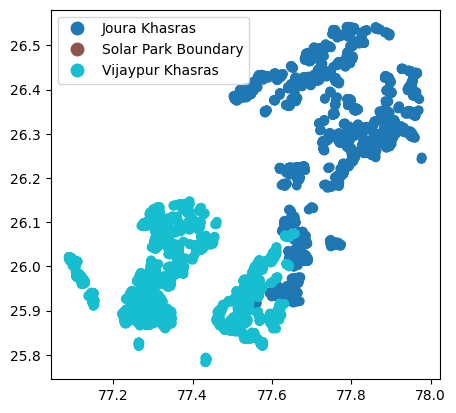

In [155]:
morena_gdf.plot(column="Source", legend=True)

In [156]:
# remove z-dimension
morena_gdf.geometry = morena_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
morena_gdf_clean = morena_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
morena_gdf_clean = morena_gdf_clean[
    morena_gdf_clean.geometry.type.isin(["Polygon", "MultiPolygon"])
]

In [157]:
len(morena_gdf_clean) == len(morena_gdf)

True

In [158]:
morena_gdf = morena_gdf.drop_duplicates(subset=["geometry"])

In [159]:
morena_gdf.shape

(8447, 10)

In [160]:
morena_gdf_clean["Khasra ID (Unique)"] = (
    morena_gdf_clean["Khasra ID"].astype(str)
    + " ("
    + morena_gdf_clean["Patch Name"].astype(str)
    + ")"
)

In [162]:
morena_gdf_clean

,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,geometry,Khasra ID (Unique)
1,104,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,5.0170पहाड 5.0170 5.0170,104,"POLYGON ((77.55342 25.90592, 77.55342 25.90598...",104 (MRA2)
3,106,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.9200पहाड 3.9200 3.9200,106,"POLYGON ((77.55297 25.90997, 77.55296 25.90997...",106 (MRA2)
5,99,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,99,"POLYGON ((77.55723 25.90691, 77.55724 25.90690...",99 (MRA2)
7,101,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,101,"POLYGON ((77.55692 25.90755, 77.55691 25.90758...",101 (MRA2)
9,103,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,103,"POLYGON ((77.55530 25.90855, 77.55477 25.90856...",103 (MRA2)
...,...,...,...,...,...,...,...,...,...,...,...
17872,Unit III,Solar Park Boundary,6,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III (6)
17873,Unit II,Solar Park Boundary,7,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64660 25.94617, 77.64650 25.94617...",Unit II (7)
17874,Unit I,Solar Park Boundary,8,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64315 25.95003, 77.64339 25.95892...",Unit I (8)
17875,Unit IV,Solar Park Boundary,9,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64695 25.92893, 77.64543 25.92955...",Unit IV (9)


#### Load Noiyat allocations and match

In [163]:
joura_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "teshil_joura_5HA_patch_identity.xlsx",
    sheet_name="identity_category",
)

vijaypur_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "Vijaypur_5ha_Identity&Patch.xlsx",
    sheet_name="Sheopur_Identity_Category",
)
vijaypur_lookup.rename(
    columns={"category": "Category"},
    inplace=True,
)

In [164]:
combined_lookup = pd.concat([joura_lookup, vijaypur_lookup], ignore_index=True)
combined_lookup = combined_lookup.sort_values(by=["Patch_name", "kid_geometry"])
combined_lookup["Category"] = combined_lookup["Category"].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
combined_lookup["Khasra ID (Unique)"] = (
    combined_lookup["kid_geometry"].astype(str)
    + " ("
    + combined_lookup["Patch_name"].astype(str)
    + ")"
)

In [165]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = combined_lookup.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True) # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

Category,Khasra ID (Unique),Noiyat Unusable Area (ha)
0,1 (MRA1421),0.000
1,1 (MRA2233),0.000
2,1 (MRA29),173.472
3,1 (MRA30),173.472
4,1 (MRA4),0.000
...,...,...
6734,998 (SEO2743),0.330
6735,998 (SEO2946),0.000
6736,999 (MRA1917),0.000
6737,999 (SEO2522),0.000


In [166]:
morena_gdf_merged = morena_gdf_clean.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
morena_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

morena_gdf_merged

,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,geometry,Khasra ID (Unique),Noiyat Unusable Area (ha)
0,104,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,5.0170पहाड 5.0170 5.0170,104,"POLYGON ((77.55342 25.90592, 77.55342 25.90598...",104 (MRA2),0.0
1,106,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.9200पहाड 3.9200 3.9200,106,"POLYGON ((77.55297 25.90997, 77.55296 25.90997...",106 (MRA2),0.0
2,99,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,99,"POLYGON ((77.55723 25.90691, 77.55724 25.90690...",99 (MRA2),0.0
3,101,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,101,"POLYGON ((77.55692 25.90755, 77.55691 25.90758...",101 (MRA2),0.0
4,103,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,103,"POLYGON ((77.55530 25.90855, 77.55477 25.90856...",103 (MRA2),0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8939,Unit III,Solar Park Boundary,6,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III (6),0.0
8940,Unit II,Solar Park Boundary,7,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64660 25.94617, 77.64650 25.94617...",Unit II (7),0.0
8941,Unit I,Solar Park Boundary,8,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64315 25.95003, 77.64339 25.95892...",Unit I (8),0.0
8942,Unit IV,Solar Park Boundary,9,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64695 25.92893, 77.64543 25.92955...",Unit IV (9),0.0


<Axes: >

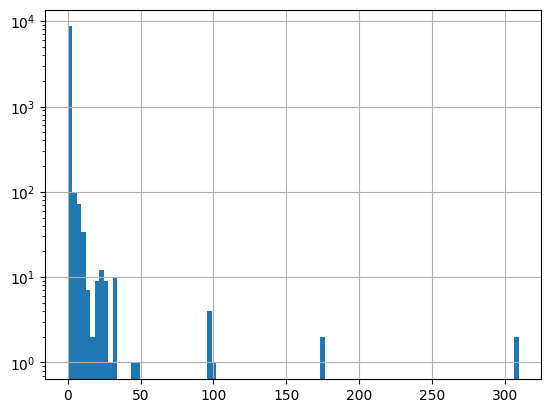

In [171]:
morena_gdf_merged["Noiyat Unusable Area (ha)"].hist(bins=100, log=True)

In [172]:
# Calculate original areas
morena_gdf_merged["Original Area (ha)"] = morena_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000

In [173]:
# add % unusable area
morena_gdf_merged["Noiyat Unusable Area (%)"] = (
    morena_gdf_merged["Noiyat Unusable Area (ha)"]
    / morena_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
morena_gdf_merged["Noiyat Unusable Area (%)"] = morena_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

In [174]:
# add 0%, 50%, 100% mapped categorical column
labels = ["0%", "1-50%", "51-99%", "100%"]
intervals = [-0.01, 1, 50, 99, 100]

morena_gdf_merged["Noiyat Unusable Area (% Category)"] = pd.cut(
    morena_gdf_merged["Noiyat Unusable Area (%)"],
    bins=intervals,
    labels=labels,
    include_lowest=True,
)

morena_gdf_merged["Noiyat Unusable Area (% Category)"] = pd.Categorical(
    morena_gdf_merged["Noiyat Unusable Area (% Category)"],
    categories=labels,
    ordered=True,
)

In [175]:
# morena_gdf_merged[(morena_gdf_merged["Noiyat % Unusable Area"] > 80) & (morena_gdf_merged["Noiyat % Unusable Area"] < 100)]
morena_gdf_merged

,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,geometry,Khasra ID (Unique),Noiyat Unusable Area (ha),Original Area (ha),Noiyat Unusable Area (%),Noiyat Unusable Area (% Category)
0,104,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,5.0170पहाड 5.0170 5.0170,104,"POLYGON ((77.55342 25.90592, 77.55342 25.90598...",104 (MRA2),0.0,0.474031,0.0,0%
1,106,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.9200पहाड 3.9200 3.9200,106,"POLYGON ((77.55297 25.90997, 77.55296 25.90997...",106 (MRA2),0.0,0.171199,0.0,0%
2,99,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,99,"POLYGON ((77.55723 25.90691, 77.55724 25.90690...",99 (MRA2),0.0,0.337680,0.0,0%
3,101,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,101,"POLYGON ((77.55692 25.90755, 77.55691 25.90758...",101 (MRA2),0.0,3.912045,0.0,0%
4,103,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,103,"POLYGON ((77.55530 25.90855, 77.55477 25.90856...",103 (MRA2),0.0,5.423501,0.0,0%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8939,Unit III,Solar Park Boundary,6,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III (6),0.0,5.831037,0.0,0%
8940,Unit II,Solar Park Boundary,7,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64660 25.94617, 77.64650 25.94617...",Unit II (7),0.0,99.140329,0.0,0%
8941,Unit I,Solar Park Boundary,8,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64315 25.95003, 77.64339 25.95892...",Unit I (8),0.0,147.992311,0.0,0%
8942,Unit IV,Solar Park Boundary,9,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((77.64695 25.92893, 77.64543 25.92955...",Unit IV (9),0.0,338.194298,0.0,0%


In [176]:
save_shapefiles(
    morena_gdf_merged,
    DATA_DIR / "01_processed" / "Solar Parks" / "Morena 2" / "01 Processed Data" / "Cleaned Khasras",
    "morena_cleaned_khasras",
    formats=["kml", "parquet", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '0%' of field morena_cleaned_khasras.Original Area (ha) parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '51-99%' of field morena_cleaned_khasras.Original Area (ha) parsed incompletely to real 51.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '100%' of field morena_cleaned_khasras.Original Area (ha) parsed incompletely to real 100.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '1-50%' of field morena_cleaned_khasras.Original Area (ha) parsed incompletely to real 1.
  ogr_write(


### Barwani

In [ ]:
barwani_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Barwani Khasras" / "barwani_khasras.kml",
    driver="KML",
)

In [ ]:
# remove z-dimension
barwani_gdf.geometry = barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
barwani_gdf = barwani_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
barwani_gdf = barwani_gdf[
    barwani_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])
]

In [ ]:
barwani_gdf.plot()

In [ ]:
barwani_gdf

In [ ]:
# no info in Description
barwani_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [ ]:
# the Name column has names like BWI20,21.382ha for patches and others are khasras
# separate those who start with BWI
barwani_patches_gdf = barwani_gdf[
    barwani_gdf["Name"].str.startswith("BWI")
]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
barwani_patches_gdf

In [ ]:
# khasras
barwani_khasra_gdf = barwani_gdf[
    ~barwani_gdf["Name"].str.startswith("BWI")
]
barwani_khasra_gdf.rename(columns={"Name": "Khasra Name"}, inplace=True)
barwani_khasra_gdf

In [ ]:
len(barwani_khasra_gdf) + len(barwani_patches_gdf) == len(barwani_gdf)

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(
    barwani_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
barwani_khasra_gdf = barwani_khasra_gdf[~barwani_khasra_gdf.index.duplicated(keep='first')]

In [ ]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

In [ ]:
barwani_khasra_gdf

#### Add unique ID column (Khasra Name is not unique across the dataset)

In [ ]:
barwani_khasra_gdf["Khasra Name"].duplicated().sum()

In [ ]:
barwani_khasra_gdf["Khasra ID"] = (
    barwani_khasra_gdf["Patch Name"] + "_khasra_" + barwani_khasra_gdf["Khasra Name"]
)
# if there are duplicates, add a suffix
barwani_khasra_gdf["Khasra ID"] = barwani_khasra_gdf["Khasra ID"].astype(str)
barwani_khasra_gdf["Khasra ID"] = barwani_khasra_gdf["Khasra ID"].where(
    ~barwani_khasra_gdf["Khasra ID"].duplicated(keep=False),
    barwani_khasra_gdf["Khasra ID"]
    + "_part_"
    + (barwani_khasra_gdf.groupby("Khasra ID").cumcount() + 1).astype(str),
)

In [ ]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

In [ ]:
# SOME KHASRAS OVERLAP!
barwani_khasra_gdf[
    barwani_khasra_gdf.duplicated(subset=["Khasra Name", "Patch Name"], keep=False)
].sort_values(by=["Khasra ID"]).iloc[2:6].plot(
    column="Khasra ID", alpha=0.2, legend=True
)

#### Cleanup and save

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf.sort_values("Khasra ID")

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf.reset_index(drop=True)

In [ ]:
barwani_khasra_gdf = barwani_khasra_gdf[
    ["Khasra ID", "Khasra Name", "Patch Name", "geometry"]
]

In [ ]:
PROCESSED_DATA_DIR_BARWANI = (
    DATA_DIR
    / "01_processed"
    / "Solar Parks"
    / "Barwani"
    / "01 Processed Data"
    / "Cleaned Khasras"
)

save_shapefiles(
    barwani_khasra_gdf,
    PROCESSED_DATA_DIR_BARWANI,
    "barwani_cleaned_khasras",
    formats=["kml", "parquet"],
)